## Multi Page OLX Real estate Scraper using Beautiful Soap 

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

# Updated BASE_URL to the house rental search format
BASE_URL = "[https://www.olx.com.pk/houses_c1721](https://www.olx.com.pk/houses_c1721)" \
""

# CRITICAL: A realistic User-Agent prevents the "Oops!" 404 error
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.google.com/"
}

MAX_PAGES = 5 
data = []

for page in range(1, MAX_PAGES + 1):
    print(f"Attempting to scrape page {page}...")
    url = BASE_URL.format(page)

    try:
        # Using the full HEADERS dictionary here is the key
        response = requests.get(url, headers=HEADERS, timeout=15)

        if response.status_code != 200:
            print(f"Page {page} blocked. Status Code: {response.status_code}")
            continue

        soup = BeautifulSoup(response.text, "html.parser")

        # OLX uses specific 'data-aut-id' attributes for its listing elements
        # This is much more reliable for your project than generic <li> or <span> tags
        listings = soup.find_all("li", {"data-aut-id": "item"})

        for item in listings:
            try:
                # Extracting specific fields for your EDA
                title = item.find("div", {"data-aut-id": "itemTitle"}).text.strip()
                price = item.find("span", {"data-aut-id": "itemPrice"}).text.strip()
                location = item.find("span", {"data-aut-id": "itemLocation"}).text.strip()

                data.append({
                    "title": title,
                    "price": price,
                    "location": location,
                    "page": page
                })
            except (AttributeError, TypeError):
                # This skips advertisements or items missing information
                continue

        # Randomized delay mimics human browsing behavior and prevents IP bans
        wait_time = random.uniform(3, 7)
        print(f"Success. Waiting {wait_time:.2f} seconds...")
        time.sleep(wait_time)

    except Exception as e:
        print(f"Error on page {page}: {e}")

# Convert to DataFrame for your Pre-processing and EDA
df = pd.DataFrame(data)

if not df.empty:
    # Save the raw data to a CSV
    df.to_csv("olx_rentals_raw.csv", index=False)
    print(f"\n--- Scraping Complete ---")
    print(f"Total listings captured: {len(df)}")
    print("File saved as: olx_rentals_raw.csv")
else:
    print("\nNo data captured. If the status code was 200, OLX is likely hiding content behind JavaScript.")

Attempting to scrape page 1...
Error on page 1: No connection adapters were found for '[https://www.olx.com.pk/houses_c1721](https://www.olx.com.pk/houses_c1721)'
Attempting to scrape page 2...
Error on page 2: No connection adapters were found for '[https://www.olx.com.pk/houses_c1721](https://www.olx.com.pk/houses_c1721)'
Attempting to scrape page 3...
Error on page 3: No connection adapters were found for '[https://www.olx.com.pk/houses_c1721](https://www.olx.com.pk/houses_c1721)'
Attempting to scrape page 4...
Error on page 4: No connection adapters were found for '[https://www.olx.com.pk/houses_c1721](https://www.olx.com.pk/houses_c1721)'
Attempting to scrape page 5...
Error on page 5: No connection adapters were found for '[https://www.olx.com.pk/houses_c1721](https://www.olx.com.pk/houses_c1721)'

No data captured. If the status code was 200, OLX is likely hiding content behind JavaScript.


## Load Librairs

In [6]:
import pandas as pd
import numpy as np

## Load Dataset 

In [15]:
df = pd.read_csv("olx_rent_data.csv")
print("Before cleaning:", df.shape)

Before cleaning: (157, 3)


## Cleaning

In [16]:
df.head()

,title,price,page
0,Lexury location Prime House For Rent,Featured,1
1,Double Storey House For Rent On Main High Cour...,Featured,1
2,House For Rent Available In Valencia Town,Featured,1
3,5 marla full house for rent,Featured,1
4,Brand New House For Rent,Featured,1


Basic Cleaning

In [17]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

Cleaning Price

In [20]:
df['price'] = df['price'].astype(str)
df['price'] = df['price'].str.replace("PKR", "")
df['price'] = df['price'].str.replace(",", "")
df['price'] = df['price'].str.extract(r'(\d+)')

df['price'] = pd.to_numeric(df['price'], errors='coerce')

now removed null values 

In [21]:
df = df.dropna(subset=['price'])

In [22]:
df.head()

,title,price,page
18,Beautiful New House For Rent In Al Hafeez Gard...,55000.0,1
19,Beautiful New House For Rent In Al Hafeez Gard...,89000.0,1
20,Brand New House For Rent In Lahore Medical Hou...,45000.0,1
21,"defence raya - 1,2,3 Bed Flats and Rooms Guest...",4500.0,1
22,Farm House For Rent With Swimming Pool On Bark...,15000.0,1


feature engenering by using colums titles into useful numeric feature

In [23]:
df['title_length'] = df['title'].apply(len)


final dataset after preprocesing 

In [26]:
df.reset_index(drop=True, inplace=True)

print("After cleaning:", df.shape)
df.head()

After cleaning: (67, 4)


,title,price,page,title_length
0,Beautiful New House For Rent In Al Hafeez Gard...,55000.0,1,52
1,Beautiful New House For Rent In Al Hafeez Gard...,89000.0,1,56
2,Brand New House For Rent In Lahore Medical Hou...,45000.0,1,58
3,"defence raya - 1,2,3 Bed Flats and Rooms Guest...",4500.0,1,116
4,Farm House For Rent With Swimming Pool On Bark...,15000.0,1,88


## Eda

To understand and then analyze the data 

Basic status plus checking missing values

In [28]:
print(df['price'].describe())
print(df.isnull().sum())

count       67.000000
mean     25530.417910
std      28220.855209
min          1.000000
25%          5.500000
50%      15000.000000
75%      43500.000000
max      95000.000000
Name: price, dtype: float64
title           0
price           0
page            0
title_length    0
dtype: int64


Skew(data is symetric or not)
Kurt(checks extreme values)

In [29]:
print("Skewness:", df['price'].skew())
print("Kurtosis:", df['price'].kurt())

Skewness: 1.1825518066612284
Kurtosis: 0.18743568308355663


Co-realtion (checks relation b/w 2 var)

In [30]:
print(df[['title_length', 'price']].corr())

              title_length     price
title_length      1.000000  0.047144
price             0.047144  1.000000


seperating data accor to pages....

In [31]:
print(df.groupby('page')['price'].mean())

page
1    34178.857143
2    28571.785714
3    17000.400000
4    28801.333333
5    16111.444444
Name: price, dtype: float64


## Visualization

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Price Distribution...

Histogram (Tells the price range of property)

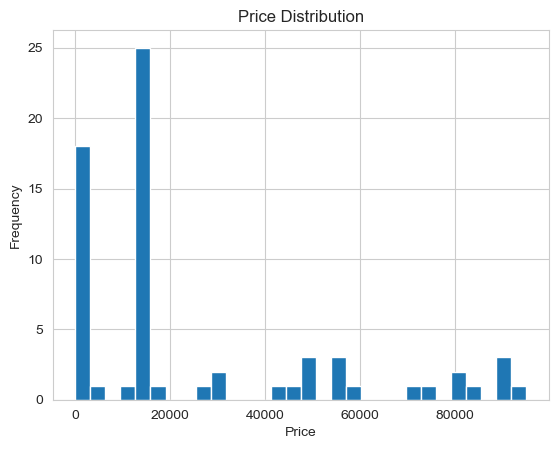

In [33]:
plt.figure()
plt.hist(df['price'], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Scatter Plot (check relationship b/w title & price)

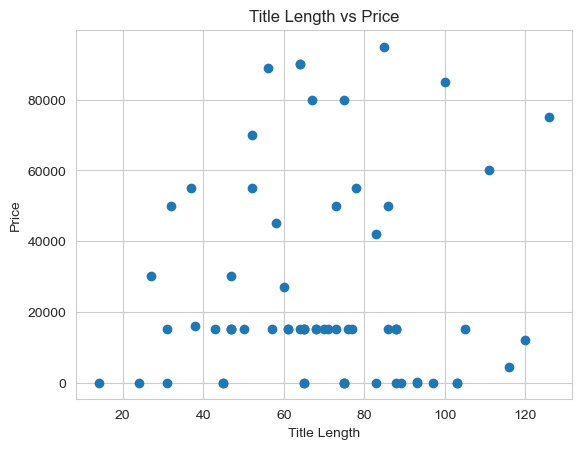

In [34]:
plt.figure()
plt.scatter(df['title_length'], df['price'])
plt.title("Title Length vs Price")
plt.xlabel("Title Length")
plt.ylabel("Price")
plt.show()


BoxPlot (compare price of every page) 

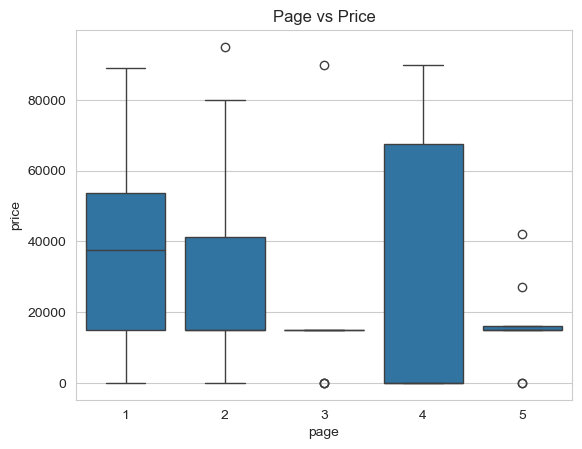

In [35]:
plt.figure()
sns.boxplot(x=df['page'], y=df['price'])
plt.title("Page vs Price")
plt.show()

Heatmap (relation of all feautures of visiual map)

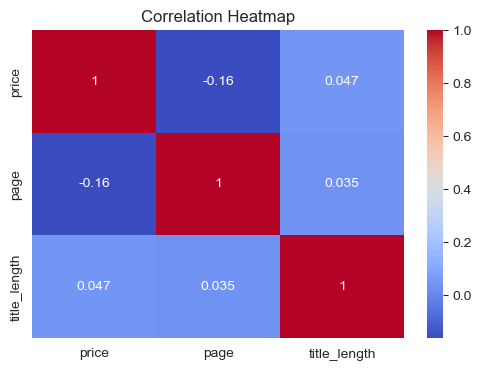

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Linear Regression

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


features

In [48]:
X = df[['title_length', 'page']]
y = df['price']

training & testing (80/20)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model 

In [41]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Prediction (predict price from new unseen data)

In [42]:
y_pred = model.predict(X_test)

Evaluation

In [43]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 17213.261239859923
R2 Score: -0.9089423741001283


In [46]:
def predict_rent(title_length, page):
    input_data = pd.DataFrame([[title_length, page]],
                              columns=['title_length', 'page'])
    
    prediction = model.predict(input_data)
    return prediction[0]

# Example
print("Predicted Rent:", predict_rent(50, 2))

Predicted Rent: 30944.249066288154


## Saving model 

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

df = pd.read_csv("olx_rent_data.csv")

# simple cleaning (same as before)
df['price'] = df['price'].astype(str).str.replace("PKR", "").str.replace(",", "")
df['price'] = df['price'].str.extract(r'(\d+)')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df.dropna(inplace=True)

df['title_length'] = df['title'].apply(len)

X = df[['title_length', 'page']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

# save model
pickle.dump(model, open("model.pkl", "wb"))

print("Model saved!")

Model saved!
